# <center> ISEL - CSM </center>
## <center>Semestre 2023/24 </center>
###  <center> Trabalho 3 - Codificação de Sinais Multimédia</center>

Trabalho realizado por:
* João Ramos, numero <b> 50730 </b>
* Miguel Alcobia, numero <b> 50746 </b>
* Fábio Pestana, numero <b> 50756 </b>

<b> Turma 42D </b> <br></br>
<b> Docente: Gonçalo Valadão </b>

### 1.
Construa uma função (codificador) que para cada bloco de 8×8 da imagem original efetue a DCT bidimensional e construa outra função (descodificador) que faça a DCT inversa. Ver funções: ``cv2.dct()`` e ``cv2.idct()``.<br>
Visualize a imagem depois da DCT e verifique que a DCT inversa resulta na imagem original.

In [156]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from time import time

import Tabelas_jpeg as tabJPG

def codificador_DCT(imagem, pb=1):
    """Codificador DCT

    Args:
        imagem: imagem a ser codificada
        pb: print boolean para imprimir valores de teste

    Returns:
        dct_imagem: valores da imagem codificados pela DCT
    """
    # Extração das dimensões da imagem
    altura, largura = imagem.shape[:2]
    # Array com a mesma forma do original para alojar os valores DCT
    dct_imagem = np.zeros_like(imagem, dtype=np.float32)

    # Percorrer blocos 8*8
    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            # Definição do bloco e recentramento do ponto médio para 0.
            bloco = imagem[y:y+8, x:x+8] - 128.

            # Prints de Teste
            if x == 0 and y == 0 and pb == 1:
                print("Bloco 1 orignial (Puro):\n")
                print(imagem[y:y+8, x:x+8],"\n")
            if x == 0 and y == 0 and pb == 1:
                print("Bloco 1 orignial (-128):\n")
                print(bloco,"\n")
            
            # Aplicação da DCT no bloco
            dct_bloco = cv.dct(np.float32(bloco))
            dct_imagem[y:y+8, x:x+8] = dct_bloco

    #cv.imwrite("Teste_DCT.jpg",dct_imagem)
    return dct_imagem

def descodificador_DCT(dct_imagem, pb=1):
    """Descodifica_DCT (aplicação de IDCT)

    Args:
        dct_imagem: Valores da imagem com DCT aplicada
        pb: print boolean para imprimir valores de teste

    Returns:
        imagem_descodificada: Valores descodificados da imagem com IDCT.
    """
    # Extração das dimensões da imagem
    altura, largura = dct_imagem.shape[:2]
    # Array com a mesma forma do original para alojar os valores DCT
    imagem_decodificada = np.zeros_like(dct_imagem, dtype=np.uint8)

    # Percorrer blocos 8*8
    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            # Aplicação da IDCT no bloco
            dct_bloco = dct_imagem[y:y+8, x:x+8]
            bloco_decodificado = (cv.idct(np.float32(dct_bloco)))

            # Prints Teste
            if x == 0 and y == 0 and pb == 1:
                print("Bloco 1 DCT:\n")
                print(dct_bloco,"\n")
                print("Bloco 1 decode DCT:\n")
                print(bloco_decodificado,"\n")
            
            imagem_decodificada[y:y+8, x:x+8] = np.uint8(bloco_decodificado +128)

    return imagem_decodificada

> Comentários:

Na primeira função ``codificador_DCT()``, recebemosa os valores da imagem original e começa-se por retirar os valores de altura e largura da mesma para criar um array com o mesmo formato que receberá os valores depois da aplicação da DCT. Em seguida, percorremos os blocos de 8*8 e aplicamo-lhes a DCT com a ajuda da função ``cv.dct()``, sendo que quando definimos o bloco subtraimos 128 de cada valor do bloco, para colocar o 0 como ponto médio da gama de valores e também diminuir o nº de bits de representa o DC, abordado mais à frente.<br><br>
Na segunda função, ``codificador_DCT()`` o procedimento é bastante semelhante, realizando a operação inversa à anterior com a aplicação da IDCT com a ``cv.idct()``.

### 2.

Construa uma função (codificador) que para cada bloco de 8 × 8 de coeficientes da transformação efectuada faça
a divisão pela matriz de quantificação (tabela K1 no anexo da norma) multiplicada por um factor de qualidade q
(ver função ``quality_factor`` do ficheiro ``Tabelas_jpeg.ipynb``). Veja a imagem com o conjunto dos blocos após
a quantificação. Construa uma função (descodificador) que realize a operação inversa da quantificação.
Junte estas funções às já realizadas e verifique para diferentes fatores de qualidade qual a SNR e veja a imagem
descodificada.

In [157]:
# Função SNR do TP1

def snr(img_org, img_app):
    """SNR - Signal-to-Noise Ratio

    Args:
        img_org: Imagem original
        img_app: Imagem com ruído

    Returns:
        snr_value: Valor do SNR
    """
    # Conversão dos valores da imagem para float
    img_org = img_org * 1.0
    img_app = img_app * 1.0

    # Calcular o sinal da imagem original
    signal = np.mean(img_org ** 2)
    
    # Calcular o ruído como a diferença entre as duas imagens (Mean-Square Error)
    noise = np.mean((img_org - img_app) ** 2)

    # Calcular a SNR (dB)
    snr_value = 10 * np.log10(signal / noise)
    return round(snr_value, 2)


In [158]:
import Tabelas_jpeg as tabJPG

def quantificar_dct(dct_imagem, q, pb=1):
    """Realiza a quantificação dos coeficientes DCT.

    Args:
        dct_imagem: Imagem DCT.
        q: Fator de qualidade.
        pb: print boolean para imprimir valores de teste

    Returns:
        dct_quantificada: Imagem com valores DCT quantificada.
    """
    # Extração das dimensões da imagem
    altura, largura = dct_imagem.shape[:2]
    # Array com a mesma forma do original para alojar os valores DCT
    dct_quantificada = np.zeros_like(dct_imagem, dtype=np.float32)

    # Fator de qualidade
    q = tabJPG.quality_factor(q)

    # Percorrer Blocos 8*8
    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            bloco = dct_imagem[y:y+8, x:x+8]
            # Aplicação do fator de qualidade na tabela K1
            matriz_quantificacao = tabJPG.Q * q
            # Calcular os coeficientes DCT quantificados
            quant_bloco = np.round(bloco / matriz_quantificacao)

            # Print Teste
            if x == y == 0 and pb == 1:
                print("Bloco 1 Quantif:\n")
                print(quant_bloco,"\n")

            dct_quantificada[y:y+8, x:x+8] = quant_bloco

    return dct_quantificada

def inversa_quantificacao(dct_quantificada, q, pb=1):
    """Realiza a inversa da quantificação.

    Args:
        dct_quantizada: Imagem quantificada.
        q: Fator de qualidade.
        pb: print boolean para imprimir valores de teste

    Returns:
        dct_desquantificada: Imagem com valores DCT descodificada.
    """
    # Extração das dimensões da imagem
    altura, largura = dct_quantificada.shape[:2]
    # Array com a mesma forma do original para alojar os valores DCT
    dct_desquantificada = np.zeros_like(dct_quantificada, dtype=np.float32)

    # Fator de qualidade
    q = tabJPG.quality_factor(q)

    # Percorrer Blocos 8*8
    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            bloco = dct_quantificada[y:y+8, x:x+8]
            # Aplicação do fator de qualidade na tabela K1
            matriz_quantificacao = tabJPG.Q * q
            # Calcular os coeficientes DCT desquantificados
            desquant_bloco = bloco * matriz_quantificacao

            # Print teste
            if x == y == 0 and pb == 1:
                print("Bloco 1 Desquantif:\n")
                print(dct_quantificada.shape)
                print(desquant_bloco,"\n")
    
            dct_desquantificada[y:y+8, x:x+8] = desquant_bloco

    return dct_desquantificada

> Comentários:

Na primeira função, ``quantificar_dct()`` ao receber os valores DCT, extraimos a altura e largura da imagem para criar um array com o mesmo formato que receberá os valores depois da quantificação dos coeficientes DCT. Calculamos o fator de qualidade recorrendo à função fornecida pelos professores ``quality_factor()`` e depois multiplicamo-lo pela tabela K1 (tabela de luminância) para obter a matriz de quantificação. Por fim, obtemos o bloco desquantificado através do produto entre o bloco com os valores DCT e a matriz de quantificação.<br><br>
Na função ``inversa_quantificacao()`` realizasse o inverso e os blocos desquantificados são obtidos quociente entre o bloco quantificado e a matriz de quantificação.

### 3.

Construa uma função (codificador) que faça a codificação diferencial dos coeficientes DC após a quantificação.<br>
Construa a função inversa para o descodificador.

In [159]:
def codificador_dc(dct_quantificada, pb=1):
    """Codificador DC

    Args:
        dct_quantificada: valores quantificados da DCT
        pb: print boolean para imprimir valores de teste

    Returns:
        _type_: _description_
    """
    # Extração da altura e largura
    altura, largura = dct_quantificada.shape[:2]
    cof_dc = []
    dc_ant = 0

    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            bloco = dct_quantificada[y:y+8, x:x+8]
            # Para cada bloco calcula-se a diferença entre o bloco atual e o anterior.
            dc = bloco[0, 0]
            dc_dif = int(dc - dc_ant)
            cof_dc.append(dc_dif)
            dc_ant = dc

    # Prints  de teste
    if pb == 1:
        print("Bloco 1 code DC:\n")
        print(cof_dc,"\n")

    return np.array(cof_dc)

def descodificador_dc(cof_dc, pb=1):
    """Descodificador DC

    Args:
        cof_dc: Valores 
        pb: print boolean para imprimir valores de teste

    Returns:
        _type_: _description_
    """
    dct_decodificada = []
    dc_ant = 0

    for dc_dif in cof_dc:
        dc = dc_ant + dc_dif
        dct_decodificada.append(dc)
        dc_ant = dc

    if pb == 1:
        print("Bloco 1 decode DC:\n")
        print(dct_decodificada,"\n")

    return np.array(dct_decodificada)


> Comentários:

Sendo que o coeficiente DC é o primeiro elemento de cada bloco da matriz da DCT, percorremos cada bloco da imagem e para cada um calcula-se a diferença entre a DC do bloco atual e a do anterior, uma vez que a variação entre os coeficientes DC não tende a ser muito grande, resulta num número mais pequeno e assim utilizamos menos espaço.<br><br>
Para a inversa em vez de subtraimos para recuperar os valores originais.

### 4.
Construa uma função (codificador) que crie um array com a indexação em zig-zag dos coeficientes AC após a
quantificação e crie um array com os pares (zero run length, nonzero value).<br>
Construa a função inversa para o descodificador.

In [160]:
def encontrar_posicao_zigzag(idx):
    """Encontrar Posição Zigzag

    Args:
        idx: valor do indice que procuramos

    Returns:
        Entradas (linha e coluna) que correspondem ao indice
    """
    for i in range(8):
        for j in range(8):
            if tabJPG.zigzag[i, j] == idx:
                return (i, j)
    return None

def cod_cof_AC(coef_quantificados):
    """Codificar Coeficentes AC

    Args:
        coef_quantificados: Coeficientes DCT quantificados

    Returns:
        cof_ac: valores codificados dos coeficientes AC em pares (zero run length, nonzero value)
    """
    
    altura, largura = coef_quantificados.shape[:2]

    cof_ac = []

    for y in range(0, altura, 8):
        for x in range(0, largura, 8):
            bloco = coef_quantificados[y:y+8, x:x+8]
            # Array 1D representa bloco de 8*8 a zeros
            coef_ac_zigzag = np.zeros(64)
            # Organização dos valores em zigzag
            for i in range(8):
                for j in range(8):
                    # Para cada valor do bloco procuramos o indice correspondente na tabela zigzag
                    idx = tabJPG.zigzag[i, j]
                    # O bloco é colocado no indice obtido a partir da tabela zigzag
                    coef_ac_zigzag[idx] = bloco[i, j]
    
            ac_pares = []
            n_zeros = 0 # número de zeros (zero run length)

            for v in range(1, 64): # Ignoramos o primeiro por ser o coef DC
                # Incrementa-se o número de zeros
                if (coef_ac_zigzag[v]==0):
                    n_zeros += 1
                else:
                    # adicionamos o par (zero run length, nonzero value)
                    ac_pares.append((n_zeros, coef_ac_zigzag[v]))
                    n_zeros = 0
        
            ac_pares.append((0, 0)) # Fim do Bloco
            ac_pares = np.asarray(ac_pares).astype(int)
            cof_ac.append(ac_pares)
    
    return np.asarray(cof_ac, dtype=object)

def decod_cof_AC(cof_ac):
    """Descodificador Coeficientes AC

    Args:
        cof_ac: Coeficientes AC codificados

    Returns:
        coef_quantificados: Coeficientes Quantificados
    """
    coef_quantificados = np.zeros([cof_ac.shape[0], 8, 8]) 
    
    for i in range(len(cof_ac)):
        idx = 1  # Ignoramos o primeiro (índice 0)
        bloco_atual = np.zeros([8, 8])  # Bloco atual de 8x8
        for j in range(len(cof_ac[i])):
            zrl = cof_ac[i][j][0] # zero run length
            nzv = cof_ac[i][j][1] # non zero value

            if zrl == nzv == 0:
                break  # Bloco final detetado
            idx += zrl # Vai até próximo valor não nulo
            # Encontra através do indice as respetivas entradas (linha, coluna) na tabela de zigzag
            posicao_zigzag = encontrar_posicao_zigzag(idx)
            if posicao_zigzag:
                # Atualiza o valor do bloco atual no indice tirado do zigzag com o non zero value
                bloco_atual[posicao_zigzag[0], posicao_zigzag[1]] = nzv
            idx += 1

        coef_quantificados[i] = bloco_atual

    return coef_quantificados

> Comentários:

Com as funções ``encontrar_posicao_zigzag()`` e ``cod_cof_AC()``, realizamos a codificação de coeficientes AC em formato zigzag. A primeira função, ``encontrar_posicao_zigzag()``, é responsável por mapear um índice que recebe para as entradas correspondentes na tabela zigzag. A função ``cod_cof_AC()`` realiza a codificação dos coeficientes AC de uma imagem DCT quantificada, organizando-os na ordem zigzag e conta os zeros consecutivos para formar os pares (zero run length, nonzero value).

Na função ``decod_cof_AC()``, fazemos o processo inverso. A descodificação segue a lógica de reverter o processo de organização em zigzag e dos pares (zero run length, nonzero value) para no fim reconstruir os blocos de coeficientes AC.

### 5.
Junte estas funções às já realizadas e veja a imagem descodificada.

In [161]:
def junta_DC_AC(val_DC, val_AC, pb =1):
    """Junta valores FC e AC

    Args:
        val_DC: Valores DC descodificados
        val_AC: Valores AC descodificados
        pb: print boolean para imprimir valores de teste

    Returns:
        Matriz com os valores DC e AC unidos
    """
    # Copia os valores de AC
    val_juntos = val_AC.copy()

    for i in range(len(val_DC)):
        # Troca o primeiro valor de AC pelo respetivo valor DC
        val_juntos[i][0][0] = val_DC[i]

    # Formatar para a forma 512, 512
    val_juntos = val_juntos.reshape(-1, val_juntos.shape[-1])
    val_juntos = np.array_split(val_juntos, len(val_juntos) // 8)

    # Inicializa a matriz final com zeros
    matriz_final = np.zeros((512, 512), dtype=val_juntos[0].dtype)

    # Preenche a matriz final com os blocos
    for i in range(len(val_juntos)):
        row = (i // 64) * 8
        col = (i % 64) * 8
        matriz_final[row:row+8, col:col+8] = val_juntos[i]

    if pb == 1:
        print("PRIMEIRO BLOCO AC_DC UNIDO:\n", matriz_final[:8, :8])

    return matriz_final

Bloco 1 orignial (Puro):

[[162 162 162 161 162 157 163 161]
 [162 162 162 161 162 157 163 161]
 [162 162 162 161 162 157 163 161]
 [162 162 162 161 162 157 163 161]
 [162 162 162 161 162 157 163 161]
 [164 164 158 155 161 159 159 160]
 [160 160 163 158 160 162 159 156]
 [159 159 155 157 158 159 156 157]] 

Bloco 1 orignial (-128):

[[34. 34. 34. 33. 34. 29. 35. 33.]
 [34. 34. 34. 33. 34. 29. 35. 33.]
 [34. 34. 34. 33. 34. 29. 35. 33.]
 [34. 34. 34. 33. 34. 29. 35. 33.]
 [34. 34. 34. 33. 34. 29. 35. 33.]
 [36. 36. 30. 27. 33. 31. 31. 32.]
 [32. 32. 35. 30. 32. 34. 31. 28.]
 [31. 31. 27. 29. 30. 31. 28. 29.]] 

Bloco 1 DCT:

[[ 2.59500000e+02  4.76826334e+00  3.24037766e+00 -1.99196100e-01
   2.50000000e-01 -5.53888500e-01 -4.58938503e+00  5.63845682e+00]
 [ 7.94733191e+00 -7.87872612e-01  5.54728985e-01 -4.93231487e+00
   1.96023726e+00  2.97842693e+00 -3.79714537e+00  3.32218695e+00]
 [-5.03491020e+00 -2.97398269e-01 -1.55177665e+00  1.72497618e+00
  -6.76495135e-01 -4.52498525e-01  1

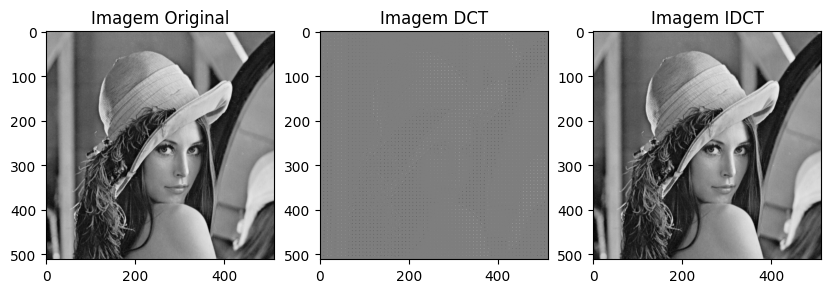

Bloco 1 Quantif:

[[16.  0.  0. -0.  0. -0. -0.  0.]
 [ 1. -0.  0. -0.  0.  0. -0.  0.]
 [-0. -0. -0.  0. -0. -0.  0. -0.]
 [ 0.  0.  0.  0. -0. -0.  0.  0.]
 [-0. -0. -0. -0.  0.  0. -0. -0.]
 [ 0.  0. -0. -0. -0.  0.  0.  0.]
 [-0.  0.  0.  0.  0. -0. -0. -0.]
 [ 0. -0. -0. -0. -0.  0.  0.  0.]] 

Bloco 1 Desquantif:

(512, 512)
[[256.   0.   0.  -0.   0.  -0.  -0.   0.]
 [ 12.  -0.   0.  -0.   0.   0.  -0.   0.]
 [ -0.  -0.  -0.   0.  -0.  -0.   0.  -0.]
 [  0.   0.   0.   0.  -0.  -0.   0.   0.]
 [ -0.  -0.  -0.  -0.   0.   0.  -0.  -0.]
 [  0.   0.  -0.  -0.  -0.   0.   0.   0.]
 [ -0.   0.   0.   0.   0.  -0.  -0.  -0.]
 [  0.  -0.  -0.  -0.  -0.   0.   0.   0.]] 

Resultado SNR_EX2 50: -0.45


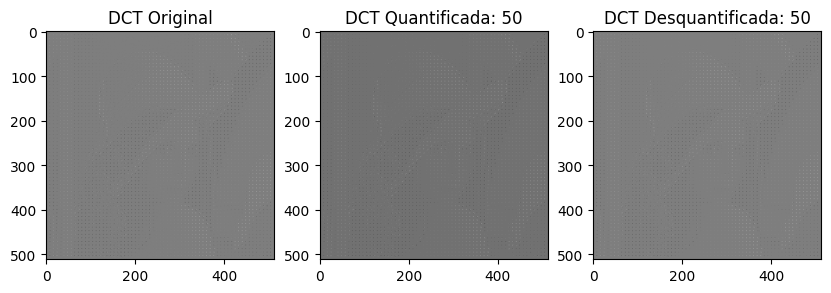

Bloco 1 code DC:

[16, -1, -1, -1, 2, 6, -1, -18, -19, 5, 1, 0, 0, 4, 4, 2, 2, 1, -1, 1, 1, 0, -1, 0, 1, 0, 0, -2, 1, -1, 2, -1, 0, -1, 0, -1, 0, 0, -3, -6, 5, 14, 5, -3, 1, 1, -2, 1, 1, 0, 11, 19, -12, -43, 6, 1, 1, 0, 1, 0, 1, -1, -2, 8, 10, 0, 0, -1, 4, 4, -4, -17, -18, 4, 3, -1, 0, 5, 4, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, -1, 1, -1, 0, 0, 1, -1, 0, 0, -1, 0, 0, 0, -3, -5, -1, 14, 9, 0, 1, 0, -1, -1, 0, -1, 2, 24, 5, -38, -13, 4, 1, -1, 1, 1, 1, 1, -15, -24, 53, 1, -1, 0, 5, -1, -3, -14, -19, 4, 3, -1, 0, 4, 4, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, -1, 0, 0, -1, 3, -1, -1, 0, -1, -1, 1, 0, -2, -4, -4, 9, 13, 5, -1, 1, -2, -1, -1, -1, -1, 11, 22, -9, -43, 2, 2, 1, 1, 2, 2, -20, -22, 0, 54, 1, 0, 3, 1, -3, 0, -16, -19, 5, 3, -1, 0, 4, 4, 2, 1, 1, 0, 1, 0, 0, 0, 0, 1, -3, -1, 1, 0, 0, 1, 1, 1, -2, 0, -1, 0, 1, -2, -3, -5, 8, 13, 5, 0, 0, -1, -1, -1, 0, -1, -2, 25, 10, -30, -23, 4, 1, 1, 3, -20, -21, -1, 3, 53, 1, 2, 2, -2, -3, 0, -16, -18, 5, 2, -1, 1, 4, 4, 1, 2, 1, -1, 1, 0, 0, 1, -1, 1, -2, -

Text(0.5, 1.0, 'Imagem Final')

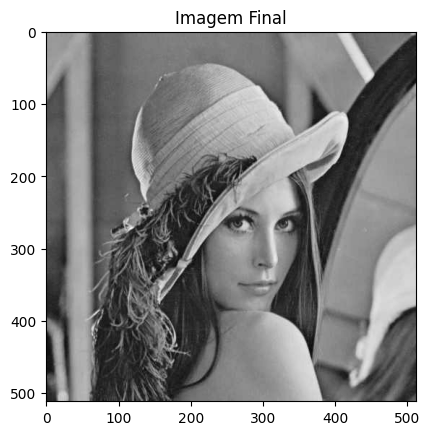

In [162]:
######################
# 1
######################
imagem_original = cv.imread('LenaGray.tif', cv.IMREAD_GRAYSCALE)

t0 = time()
imagem_dct = codificador_DCT(imagem_original)
t1 = time()

imagem_idct = descodificador_DCT(imagem_dct)
# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagem_original, cmap='gray')
plt.title('Imagem Original')

plt.subplot(1, 3, 2)
plt.imshow(imagem_dct, cmap='gray')
plt.title('Imagem DCT')

plt.subplot(1, 3, 3)
plt.imshow(imagem_idct, cmap='gray')
plt.title('Imagem IDCT')

plt.show()

######################
# 2
######################

q = 50
dct_quantificada=  quantificar_dct(imagem_dct, q)
dct_desquantificada = inversa_quantificacao(dct_quantificada, q)
snr_ex2 = snr(imagem_original, dct_desquantificada)
print(f"Resultado SNR_EX2 {q}:", snr_ex2)

#print("TESTE_ORG:\n", len(dct_quantificada[0]))

# DESCOMENTAR PARA MELHOR VISIBILDIADE

"""
cv.imshow(f"Teste quant1: {q}", imagem_dct)
cv.imshow(f"Teste quant2: {q}", dct_quantificada)
cv.imshow(f"Teste quant3: {q}", dct_desquantificada)
cv.waitKey(0) 
cv.destroyAllWindows()
"""


# Plots
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagem_dct, cmap='gray')
plt.title('DCT Original')

plt.subplot(1, 3, 2)
plt.imshow(dct_quantificada, cmap='gray')
plt.title(f'DCT Quantificada: {q}')

plt.subplot(1, 3, 3)
plt.imshow(dct_desquantificada, cmap='gray')
plt.title(f'DCT Desquantificada: {q}')

plt.show()
#snr = calcular_SNR(imagem, imagem_descodificada)
#print(f"Fator de Qualidade: {q}, SNR: {snr}")

######################
# 3
######################
imagem_dc = codificador_dc(dct_quantificada)
imagem_dc_inv = descodificador_dc(imagem_dc)

######################
# 4
###################### 
cod_AC = cod_cof_AC(dct_quantificada)
"""
print("Bloco 1 code AC:\n")
print(cod_AC[0],"\n")
print(cod_AC[1],"\n")
print(cod_AC[2],"\n")
"""

decod_AC = decod_cof_AC(cod_AC)
"""
print("Bloco 1 decode AC:\n")
print(decod_AC[0],"\n")
"""

######################
# 5
######################

# Continuando a partir dos passos já realizados

val_dc_ac = junta_DC_AC(imagem_dc_inv, decod_AC) 

# 
val_desquantif = inversa_quantificacao(val_dc_ac, q)

#
val_idct = descodificador_DCT(val_desquantif)
"""
print("Valores IDCT Final:\n")
print(val_idct[0],"\n")
"""

"""
cv.imshow(f"Resultado", val_idct)
cv.waitKey(0) 
cv.destroyAllWindows()
"""

plt.plot()
plt.imshow(val_idct, cmap='gray')
plt.title('Imagem Final')

> Comentários:

Nesta função apenas substituimos o primeiro valor de cada matriz AC para o valor DC correspondente e no fim, organizamos os blocos para ficar uma matriz 512*512 como a imagem original.

### 6.
Construa uma função que dados os arrays das alíneas anteriores use as tabelas do código de Huffman (tabela K3
e K5) e grave num ficheiro a sequência de bits correspondente. (não é necessário usar o formato JFIF)

In [163]:
def complemento_bin(bin_numb):
    """Complemento de 1 para número binários

    Args:
        bin_numb: número binário a converter

    Returns:
        str_bin: inverso de bin_numb pelo complemento de 1
    """
    str_bin = ""
    
    for i in range(len(bin_numb)): 
        str_bin +=  '1' if (bin_numb[i] == '0') else '0'
            
    return str_bin

def tab_K3_K5(decod_DC, decod_AC):
    """_summary_

    Args:
        decod_DC: Valores DC descodificados
        decod_AC: Valores AC descodificados

    Returns:
        Valores DC e AC codificados pelas tabelas K3 e K5
    """    
    str_code = ""

    # Bloco DC    
    for i in range(len(decod_DC)):
        # Tratamento de números negativos
        if decod_DC[i] < 0:
            bin_block_DC = bin(decod_DC[i])[3:]
            bin_block_DC = complemento_bin(bin_block_DC)
            str_code += tabJPG.K3[len(bin_block_DC)]        # Size
            str_code += bin_block_DC                        # Amplitude
        elif(decod_DC[i] > 0):
            bin_block_DC = bin(decod_DC[i])[2:]
            str_code += tabJPG.K3[len(bin_block_DC)]
            str_code += bin_block_DC
        else:
            str_code += tabJPG.K3[0]
    
        # Bloco AC
        for j in range(len(decod_AC[i])):
            valor_AC = decod_AC[i][j]
            if(valor_AC[0] == 0 and valor_AC[1] == 0):  # Fim do bloco
                str_code += tabJPG.K5[(0,0)]
            else:
                v1 = valor_AC[0]                        # Zero Runlength
                if valor_AC[1] > 0:                     # NonZero Value
                    bin_num = bin(valor_AC[1])[2:]
                    size = len(bin_num)
                elif valor_AC[1] < 0:
                    bin_num = bin(valor_AC[1])[3:]      # ignora "-0b"
                    bin_num = complemento_bin(bin_num)
                    size = len(bin_num)
                else:
                    size = 0
                    bin_num = ""
                # Supera o suportado pela tabela
                if (v1 > 15):
                    v1 = 0
                
                str_code += tabJPG.K5[(v1, size)]
                str_code += bin_num

    return str_code

# Função do TP2
def write2file(seq_bits, file_name):
    """Grava um sequência de bits para um ficheiro

    Args:
        seq_bits: Sequência de bits a gravar no ficheiro
        file_name: Nome do ficheiro, onde se vai gravar a sequência
    """

    file = open(file_name, 'w')
    for bit in seq_bits:
        file.write(str(bit))
    file.close()

def read_file(file_name):
    """Read File

    Args:
        file_name: Nome do ficheiro

    Returns:
        mensagem contida no ficheiro
    """
    
    with open(file_name, "r") as file:
        msg = file.read()
    
    return msg

In [164]:
k3_k5_huff = tab_K3_K5(imagem_dc, cod_AC)

write2file(k3_k5_huff, "lena_k3_k5.txt")

> Comentários:

Nas funções ``complemento_bin()`` e ``tab_K3_K5()``, realizamos a codificação de valores DC e AC em binário, utilizando as tabelas K3 e K5 para a representação dos valores. A função ``complemento_bin()`` é responsável por calcular o complemento de 1 para números binários, para a representação de números negativos.
<br><br>
A função ``tab_K3_K5()`` com a ajuda das tabelas K3 e K5 converte os valores DC e AC de uma imagem DCT em uma sequência binária.
Os valores DC são representados por um par [Size, Amplitude], de acordo com a tabela K3, onde Size indica a quantidade de bits que codificam o campo Amplitude.
Por exemplo temos o número 16, o seu binário fica 10000 que tem comprimento igual a 5 logo o valor a retirar da tabela k3 é K3[5] = 110.<br><br>
Nos valores AC temos apresentados pares [Zero run length, nonzero value], onde o nonzero value é passado para binário, seguido do valor de zero run length do valor também em binário.
Com o valor de Zero run length e o comprimento do valor binário de nonzero value, atribui-se o respetivo código da tabela K5, Ao encontrar o par [0,0] é detetado o final do bloco, regressando à codificação da componente DC.
<br><br>
Por fim, a função ``write2file()`` é uma utilidade para escrever uma sequência de bits num arquivo, enquanto ``read_file()`` é usada para ler o conteúdo de um ficheiro.

#### 7.

Construa uma função que leia o ficheiro gravado e retorne os arrays com os coeficientes AC e DC.

In [165]:
def procurar_val_tab_K3(seq_DC):
    """Procura valor na tabela K3

    Args:
        seq_DC: Sequência a ser encontrada na tabela

    Returns:
        procura, indice_tab: boolean que indica se seq_DC existe na tabela K3 e indice_tab tem o respetivo indice.
    """

    procura = seq_DC in list(tabJPG.K3.values())
    
    if procura:
        indice_tab = list(tabJPG.K3.keys())[list(tabJPG.K3.values()).index(seq_DC)]
        return procura, indice_tab
    else:
        return procura, None
        

def procurar_val_tab_K5(seq_AC):
    """Procura valor na tabela K5

    Args:
        seq_DC: Sequência a ser encontrada na tabela

    Returns:
        procura, indice_tab: boolean que indica se seq_DC existe na tabela K3 e indice_tab tem o respetivo indice.
    """
    procura = seq_AC in list(tabJPG.K5.values())

    if procura:   
        indice_tab = list(tabJPG.K5.keys())[list(tabJPG.K5.values()).index(seq_AC)]
        return procura, indice_tab
    else:
        return procura, None
    
def decode_K3_K5(seq):
    """Descodifica a mensagem codificada pelas tabelas K3 e K5

    Args:
        seq: mensagem a descodificar

    Returns:
        final_val_DC, final_val_AC: Valores DC e AC codificados
    """
    
    final_val_DC = []
    final_val_AC = []

    while (len(seq)>0):
        seq_DC = ""
        seq_AC = ""
        AC_pares = []
        find_DC = False
        end_block = False
        seq_end_block = tabJPG.K5[(0, 0)] # 1010

        idx_bit = 0

        # Bloco DC
        while not find_DC:
            seq_DC += seq[idx_bit]
            idx_bit += 1
            check_find_DC = procurar_val_tab_K3(seq_DC)[0]
            if check_find_DC:
                find_DC = True
                seq = seq[idx_bit:] # remoção da sequência encontrada
                len_bits_DC = procurar_val_tab_K3(seq_DC)[1]
                
                val_bin_DC = seq[:len_bits_DC]
                seq = seq[len_bits_DC:]

                if len_bits_DC == 0:
                    val_dc = 0
                else:
                    if val_bin_DC[0] == "0":
                        val_dc = - int(complemento_bin(val_bin_DC), 2)
                    else:
                        val_dc = int(val_bin_DC, 2)
                
                final_val_DC.append(val_dc)

        idx_bit = 0
        
        # Bloco AC
        while not end_block:
            seq_AC += seq[idx_bit]
            idx_bit += 1

            check_find_AC = procurar_val_tab_K5(seq_AC)[0]
            if check_find_AC:
                seq = seq[idx_bit:]

                if seq_AC == seq_end_block:
                    end_block = True
                    AC_pares.append([0,0])
                    final_val_AC.append(AC_pares)
                else:
                    par_bits_AC = procurar_val_tab_K5(seq_AC)[1]
                    n_zeros = par_bits_AC[0]
                    size = par_bits_AC[1]

                    if size != 0:
                        val_ac = seq[:size]
                        seq = seq [size:]

                        if val_ac[0] == "0":
                            AC_pares.append([n_zeros, - int(complemento_bin(val_ac), 2)])
                        else:
                            AC_pares.append([n_zeros, int(val_ac, 2)])
                    else:
                        AC_pares.append([n_zeros, size])
                
                seq_AC = ""
                idx_bit = 0

    final_val_DC = np.array(final_val_DC) 
    final_val_AC = np.asarray(final_val_AC, dtype="object")
    #print(final_val_DC)
        
    return final_val_DC, final_val_AC

> Comentários:

Nas funções ``procurar_val_tab_K3()``, ``procurar_val_tab_K5()``, e ``decode_K3_K5()``, decodificamos os valores DC e AC que foram codificados com as tabelas K3 e K5. 

A função ``procurar_val_tab_K3()`` procura um valor na tabela K3, enquanto ``procurar_val_tab_K5()`` faz o mesmo para a tabela K5. 

A função ``decode_K3_K5()`` é responsável por decodificar a sequência binária codificada utilizando as tabelas K3 e K5. Percorremos a sequência binária, identificando e convertendo os valores DC e AC de volta aos seus valores originais, de acordo com as especificações das tabelas K3 e K5.

In [166]:
seq = read_file("lena_k3_k5.txt")

decode_K3_K5_DC, decode_K3_K5_AC = decode_K3_K5(seq)

img_decode_DC = descodificador_dc(decode_K3_K5_DC)
img_decode_AC = decod_cof_AC(decode_K3_K5_AC)

img_junta_DC_AC_K3_k5 = junta_DC_AC(img_decode_DC, img_decode_AC)

img_desquantif_dct_K3_K5 = inversa_quantificacao(img_junta_DC_AC_K3_k5, q)

img_idct_K3_K5 = descodificador_DCT(img_desquantif_dct_K3_K5)

cv.imshow(f"Resultado Final depois das tabelas", img_idct_K3_K5)
cv.waitKey(0) 
cv.destroyAllWindows()

Bloco 1 decode DC:

[16, 15, 14, 13, 15, 21, 20, 2, -17, -12, -11, -11, -11, -7, -3, -1, 1, 2, 1, 2, 3, 3, 2, 2, 3, 3, 3, 1, 2, 1, 3, 2, 2, 1, 1, 0, 0, 0, -3, -9, -4, 10, 15, 12, 13, 14, 12, 13, 14, 14, 25, 44, 32, -11, -5, -4, -3, -3, -2, -2, -1, -2, -4, 4, 14, 14, 14, 13, 17, 21, 17, 0, -18, -14, -11, -12, -12, -7, -3, -1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, -3, -8, -9, 5, 14, 14, 15, 15, 14, 13, 13, 12, 14, 38, 43, 5, -8, -4, -3, -4, -3, -2, -1, 0, -15, -39, 14, 15, 14, 14, 19, 18, 15, 1, -18, -14, -11, -12, -12, -8, -4, -2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 3, 2, 1, 1, 0, -1, 0, 0, -2, -6, -10, -1, 12, 17, 16, 17, 15, 14, 13, 12, 11, 22, 44, 35, -8, -6, -4, -3, -2, 0, 2, -18, -40, -40, 14, 15, 15, 18, 19, 16, 16, 0, -19, -14, -11, -12, -12, -8, -4, -2, -1, 0, 0, 1, 1, 1, 1, 1, 2, -1, -2, -1, -1, -1, 0, 1, 2, 0, 0, -1, -1, 0, -2, -5, -10, -2, 11, 16, 16, 16, 15, 14, 13, 13, 12, 10, 35, 45, 15, -8, -4, -3, -2, 1, -19, -40, -41, -38, 15, 16, 18, 2

### 8.
Junte estas funções às já realizadas e veja a imagem descodificada.
Para diferentes factores de qualidade meça a relação sinal-ruído e a taxa de compressão obtida. Represente um
gráfico onde se apresente a taxa de compressão em função do SNR. 

### 9.
No mesmo gráfico compare o seu compressor de imagem com outros existentes para várias qualidades.

In [167]:
# Taxa de Compressao (TP1 com alguns ajustes):
#   tamanho Imagem Original / tamanho Imagem alterada
def taxaCompressao(img_org_size, img_app_size):
    """Taxa de Compressão

    Calcula a taxa de compressão entre o tamanho da imagem original e a imagem alterada

    Args:
        img_org_size: Tamanho da imagem original
        img_app_size: Tamanho da imagem alterada
    Returns:
        factor_qualidade: Taxa de compressão
    """
    factor_qualidade = img_org_size/img_app_size
    return np.round(factor_qualidade)

Tamanho Imagem original: 210122
Dados da qualidade com funcoes dos alunos: Qualidade10

Tamanho JPG: 23415
	SNR: 24.59
	Taxa de compressão: 9.0 

Dados da qualidade do CloudConverter: Qualidade 10

Tamanho JPG: 6549
	SNR: 24.75
	Taxa de compressão: 32.0 

Dados da qualidade com funcoes dos alunos: Qualidade20

Tamanho JPG: 32944
	SNR: 27.25
	Taxa de compressão: 6.0 

Dados da qualidade do CloudConverter: Qualidade 20

Tamanho JPG: 10812
	SNR: 27.29
	Taxa de compressão: 19.0 

Dados da qualidade com funcoes dos alunos: Qualidade30

Tamanho JPG: 39775
	SNR: 28.53
	Taxa de compressão: 5.0 

Dados da qualidade do CloudConverter: Qualidade 30

Tamanho JPG: 14408
	SNR: 28.6
	Taxa de compressão: 15.0 

Dados da qualidade com funcoes dos alunos: Qualidade40

Tamanho JPG: 43553
	SNR: 29.42
	Taxa de compressão: 5.0 

Dados da qualidade do CloudConverter: Qualidade 40

Tamanho JPG: 17604
	SNR: 29.41
	Taxa de compressão: 12.0 

Dados da qualidade com funcoes dos alunos: Qualidade50

Tamanho JPG: 4

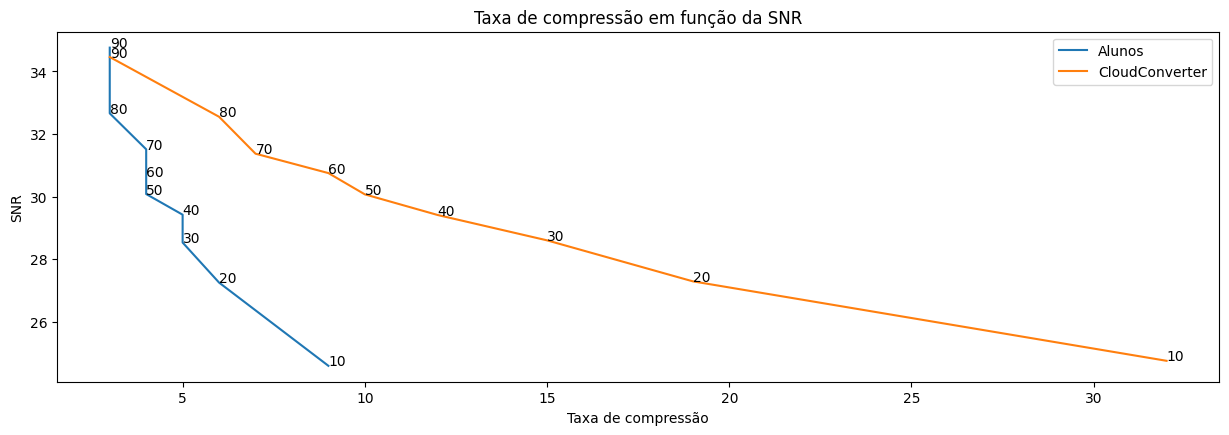

In [168]:
from os import path

size_img_original = path.getsize("LenaGray.tif")
print("Tamanho Imagem original:", size_img_original)

qualidade = [10, 20, 30, 40, 50, 60, 70, 80, 90]
SNRs = []
TaxaComp = []
Times = []

SNRs_CC = []
TaxaComp_CC = []

for q in qualidade:
    t2 = time()
    dct_quantificada=  quantificar_dct(imagem_dct, q, 0)

    imagem_dc = codificador_dc(dct_quantificada, 0)

    cod_AC = cod_cof_AC(dct_quantificada)

    k3_k5_huff = tab_K3_K5(imagem_dc, cod_AC)

    # Escrita no ficheiro

    write2file(k3_k5_huff, f"lena_k3_k5_{q}.txt")

    seq = read_file(f"lena_k3_k5_{q}.txt")

    # Descodificação

    decode_K3_K5_DC, decode_K3_K5_AC = decode_K3_K5(seq)

    img_decode_DC = descodificador_dc(decode_K3_K5_DC, 0)
    img_decode_AC = decod_cof_AC(decode_K3_K5_AC)

    img_junta_DC_AC_K3_k5 = junta_DC_AC(img_decode_DC, img_decode_AC, 0)

    img_desquantif_dct_K3_K5 = inversa_quantificacao(img_junta_DC_AC_K3_k5, q, 0)

    img_idct_K3_K5 = descodificador_DCT(img_desquantif_dct_K3_K5, 0)

    t3 = time()

    time_final = (t3-t2) + (t1-t0)
    Times.append(time_final)

    #print("SHAPE:", img_idct_K3_K5.shape)

    str_img_jpg = "Lena_JPG_" + str(q) +" .jpg"

    cv.imwrite(str_img_jpg, img_idct_K3_K5)

    size_img_jpg = path.getsize(str_img_jpg)

    #### SNR e Taxa de Comp ####

    img_JPG = cv.imread(str_img_jpg,  cv.IMREAD_GRAYSCALE)
    snr_valor = snr(imagem_original, img_JPG)
    taxaComp = taxaCompressao(size_img_original, size_img_jpg)

    SNRs.append(snr_valor)
    TaxaComp.append(taxaComp)

    print(f"Dados da qualidade com funcoes dos alunos: Qualidade{q}\n")
    print("Tamanho JPG:", size_img_jpg)
    print("\tSNR:", snr_valor)
    print("\tTaxa de compressão:", taxaComp,"\n")

    # Imagens CloudConverter

    img_Cloud = cv.imread(f"cloudconvert/LenaGray-C{q}.jpg",  cv.IMREAD_GRAYSCALE)
    size_img_cloud = path.getsize(f"cloudconvert/LenaGray-C{q}.jpg")

    snr_valor = snr(imagem_original, img_Cloud)
    taxaComp = taxaCompressao(size_img_original, size_img_cloud)

    SNRs_CC.append(snr_valor)
    TaxaComp_CC.append(taxaComp)

    print(f"Dados da qualidade do CloudConverter: Qualidade {q}\n")
    print("Tamanho JPG:", size_img_cloud)
    print("\tSNR:", snr_valor)
    print("\tTaxa de compressão:", taxaComp,"\n")

    """
    cv.imshow(f"Resultado Final após tabelas {q}", img_idct_K3_K5)
    cv.waitKey(0) 
    cv.destroyAllWindows()
    """

plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.plot(TaxaComp, SNRs, label = "Alunos")
plt.plot(TaxaComp_CC, SNRs_CC, label="CloudConverter")
plt.title("Taxa de compressão em função da SNR")
plt.legend()
plt.xlabel("Taxa de compressão")
plt.ylabel("SNR")
for i in range(len(qualidade)):
    plt.annotate(str(qualidade[i]), xy=(TaxaComp[i], SNRs[i]))
    plt.annotate(str(qualidade[i]), xy=(TaxaComp_CC[i], SNRs_CC[i]))

> Comentários:

Conseguimos, visualmente, resultados satisfatórios na reconstrução da imagem em diversas qualidades. Utilizamos para comparação o conversor online CloudConverter. O gráfico acima demonstra a comparação dos resultados obtidos. Podemos perceber que Os valores de SNR estão bastante próximos, contudo a taxa de compressão afasta-se consideravelmente do suposto e acreditamos que este problema provenha da codificação e/ou descodfificação das tabelas K3 e K5.

> Tabela

In [169]:
# Cabeçalho da tabela
print("|    SNR     | Taxa de Comp |  Tempo (s)  |")
print("|------------|--------------|-------------|")

# Preenchendo a tabela com os valores dos arrays
for snr, taxa, tempo in zip(SNRs, TaxaComp, Times):
    snr_str = f"{snr:.2f}".center(10)
    taxa_str = f"{taxa:.1f}".center(12)
    tempo_str = f"{tempo:.7f}".center(11)
    print(f"| {snr_str} | {taxa_str} | {tempo_str} |")

|    SNR     | Taxa de Comp |  Tempo (s)  |
|------------|--------------|-------------|
|   24.59    |     9.0      |  0.6535053  |
|   27.25    |     6.0      |  1.1786692  |
|   28.53    |     5.0      |  1.0935261  |
|   29.42    |     5.0      |  1.6846826  |
|   30.08    |     4.0      |  1.3988311  |
|   30.63    |     4.0      |  1.5987720  |
|   31.51    |     4.0      |  1.9742453  |
|   32.66    |     3.0      |  16.3098874 |
|   34.76    |     3.0      |  4.6623070  |
